Agent-based model for our paper on policy decisions in the context of fast science

In [61]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

class Simulation:
    def __init__(self,
                 fp_cost=-5,
                 fn_cost=-100,
                 minority_type='expert',
                 base_penalty=0.05,        # NEW: How much trust
                                           # is lost on error (0.01 to 0.5)
                 mitigation_factor=1.0,
                 ground_p = .3,
                 leaning_p = .6,
                 polarization_p = .2,
                 leaning_maj_mean_l = .2,
                 leaning_maj_mean_u = .4 # was .4
                 ):
                                           # excuse the error? (0.0 = None, 1.0 = Full)

        self.fp_cost = fp_cost
        self.fn_cost = fn_cost
        self.minority_type = minority_type
        self.base_penalty = base_penalty
        self.mitigation_factor = mitigation_factor
        self.ground_p = ground_p
        self.leaning_p = leaning_p
        self.polarization_p = polarization_p
        self.leaning_maj_mean_l = leaning_maj_mean_l
        self.leaning_maj_mean_u = leaning_maj_mean_u
        self.trust_scores = {'Majority': 1.0, 'Levi': 1.0}
        self.utilities = {'Majority': 0, 'Levi': 0}

    def run_round(self):

        # 1. Ground Truth (30% chance of Danger)
        ground_truth = np.random.choice([0, 1], p=[1 - self.ground_p,self.ground_p])

        # 2. Scenario Generation (Focus on A_leaning/Polarization)
        scenario = np.random.choice(['weak_evidence', 'polarization',
                                     'A_leaning'], p=[1- (self.leaning_p + self.polarization_p),
                                                      self.polarization_p,
                                                      self.leaning_p])

        # 3. Expert Opinion Generation
        n_experts = 5
        experts = []

        if scenario == 'weak_evidence':
            experts = np.random.normal(0.5, 0.15, n_experts)
            eo = np.clip(experts, 0.01, 0.99)
            dec_maj = 1 if np.mean(eo) > 0.6 else 0
            dec_levi = 1 if np.max(eo) > 0.8 else 0

        elif scenario == 'polarization':
            experts = np.concatenate([np.random.normal(0.2, 0.05, 3),
                                      np.random.normal(0.8, 0.05, 2)])
            eo = np.clip(experts, 0.01, 0.99)
            dec_maj = 1 if np.mean(eo) > 0.6 else 0
            dec_levi = 1 if np.max(eo) > 0.8 else 0

        elif scenario == 'A_leaning':
            # majority is conservative
            maj_mean = self.leaning_maj_mean_l if ground_truth == 0 else self.leaning_maj_mean_u
            majority = np.random.normal(maj_mean, 0.1, n_experts - 1)
            majority = np.clip(majority, 0.01, 0.99)

            # minority
            if self.minority_type == 'expert':
                minority_val = np.random.normal(0.85, .1, 1) if ground_truth == 1 else np.random.normal(0.3, .1, 1)
            else: # crank always screams wolf
                minority_val = np.random.normal(0.85, .1, 1)

            experts = np.append(majority, minority_val)
            eo = np.clip(experts, 0.01, 0.99)
            # dec_maj = 1 if np.mean(majority) > 0.6 else 0  # dec_maj ignores minority
            dec_maj = 1 if np.mean(eo) > 0.6 else 0
            dec_levi = 1 if np.max(eo) > 0.8 else 0

        # eo = np.clip(experts, 0.01, 0.99)

        # 4. Decisions
        # dec_maj = 1 if np.mean(eo) > 0.6 else 0
        # dec_levi = 1 if np.max(eo) > 0.8 else 0 # precautionary trigger

        # 5. Calculate Utility for this round
        # Matrix: TP=+10, TN=0, FP=fp_cost, FN=fn_cost
        def get_util(dec, truth):
            if dec == 1 and truth == 1: return 10
            if dec == 0 and truth == 0: return 0
            if dec == 1 and truth == 0: return self.fp_cost
            if dec == 0 and truth == 1: return self.fn_cost
            return 0

        self.utilities['Majority'] += get_util(dec_maj, ground_truth)
        self.utilities['Levi'] += get_util(dec_levi, ground_truth)

        # 6. Update Trust
        def update_t(policy, dec):
            current = self.trust_scores[policy]
            if dec == ground_truth:
                return min(1.0, current + 0.01) # Slow recovery
            else:
                # Calculate Penalty
                penalty = self.base_penalty

                # Mitigation Logic
                # Levi communicates the spread.
                if policy == 'Levi':
                    spread = np.max(eo) - np.min(eo)
                    # If factor is 1.0, high spread eliminates penalty.
                    # If factor is 0.0, spread is ignored (Outcome Bias).
                    penalty = penalty * (1 - (spread * self.mitigation_factor))

                return max(0.0, current - penalty)

        self.trust_scores['Majority'] = update_t('Majority', dec_maj)
        self.trust_scores['Levi'] = update_t('Levi', dec_levi)

Test suite 1:
- tipping point - costs

Running sweep for Inconvenience Cost...
Running sweep for Inconvenience Cost...
Running sweep for Inconvenience Cost...


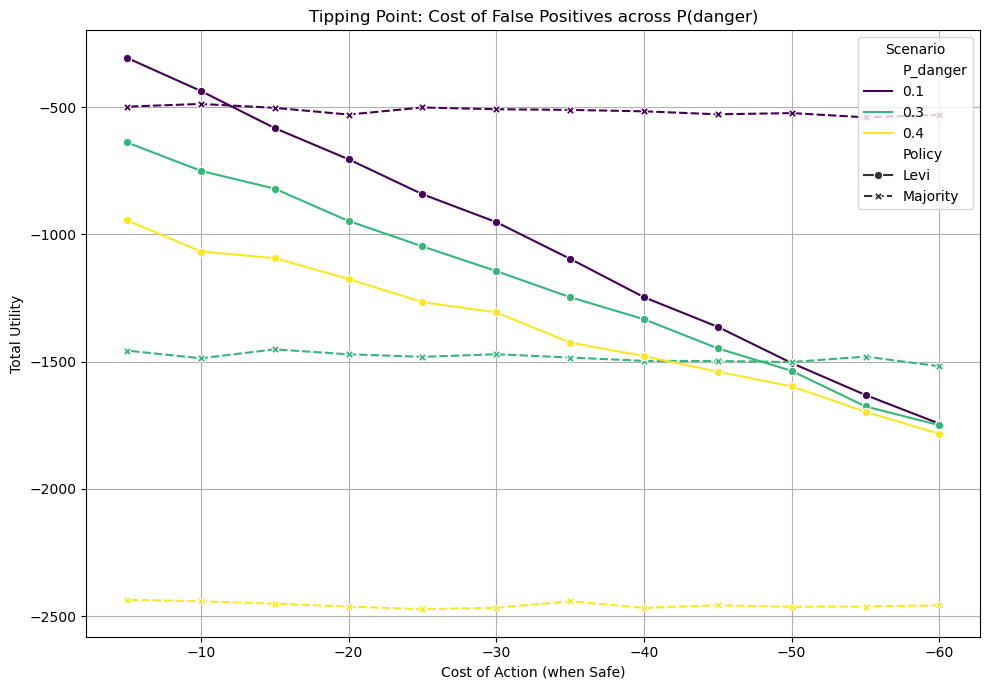

Running sweep for Inconvenience Cost...
Running sweep for Inconvenience Cost...
Running sweep for Inconvenience Cost...


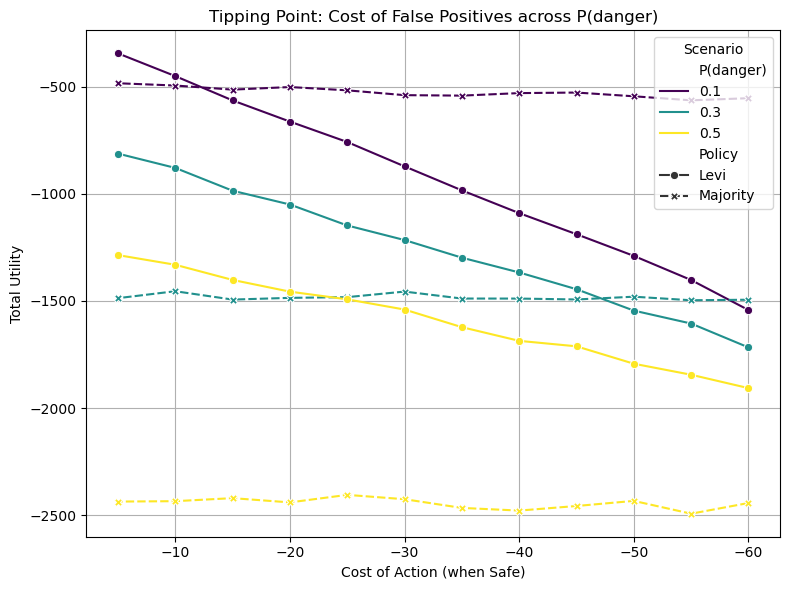

In [82]:
def run_test_suite(parameter_name, parameter_values, ground_truth_prob,
                   leaning_prob, polarization_prob, fpcost, n_runs=400):
    results = []

    print(f"Running sweep for {parameter_name}...")

    for val in parameter_values:
        levi_utils = []
        maj_utils = []
        levi_trusts = []
        maj_trusts = []

        for _ in range(n_runs):
            # Dynamic kwargs based on what we are testing
            kwargs = {
                'fp_cost': fpcost,
                'minority_type': 'crank', # Default to Crank to stress-test Levi
                'ground_p': ground_truth_prob,
                'leaning_p': leaning_prob,
                'polarization_p': polarization_prob,
                'leaning_maj_mean_u': .4,
            }

            # Inject the sweep parameter
            if parameter_name == 'Inconvenience Cost':
                kwargs['fp_cost'] = val
            elif parameter_name == 'Minority Accuracy':
                # varying probability that minority is expert vs crank
                is_expert = np.random.rand() < val
                kwargs['minority_type'] = 'expert' if is_expert else 'crank'
            elif parameter_name == 'Majority Accuracy':
                kwargs['leaning_maj_mean_u'] = val

            # Run Sim
            sim = Simulation(**kwargs)
            # Run 50 rounds per sim
            for _ in range(50):
                sim.run_round()

            levi_utils.append(sim.utilities['Levi'])
            maj_utils.append(sim.utilities['Majority'])
            levi_trusts.append(sim.trust_scores['Levi'])
            maj_trusts.append(sim.trust_scores['Majority'])

        results.append({
            'Parameter': val,
            'Levi_Util_Mean': np.mean(levi_utils),
            'Maj_Util_Mean': np.mean(maj_utils),
            'Levi_Trust_Mean': np.mean(levi_trusts),
            'Maj_Trust_Mean': np.mean(maj_trusts)
        })

    return pd.DataFrame(results)


# TEST 1: The Tipping Point of Cost
# We vary the cost of a False Positive from -5 (Masks) to -60 (Lockdown?)
# We keep the minority as 'crank' to see when the false alarms become too
# expensive.

df_cost = run_test_suite('Inconvenience Cost', range(-5, -65, -5), .3, .6, .2, -5)
df_cost2 = run_test_suite('Inconvenience Cost', range(-5, -65, -5), .1, .6, .2, -5)
df_cost3 = run_test_suite('Inconvenience Cost', range(-5, -65, -5), .5, .6, .2, -5)

# --- PLOTTING ---
# Combine dataframes for easier plotting with seaborn
df_cost_combined = pd.DataFrame()

# Process df_cost (P(danger)=0.3)
df_temp = df_cost.copy()
df_temp['P_danger'] = 0.3
df_levi = df_temp[['Parameter', 'Levi_Util_Mean', 'P_danger']].rename(columns={'Levi_Util_Mean': 'Utility_Mean'})
df_levi['Policy'] = 'Levi'
df_maj = df_temp[['Parameter', 'Maj_Util_Mean', 'P_danger']].rename(columns={'Maj_Util_Mean': 'Utility_Mean'})
df_maj['Policy'] = 'Majority'
df_cost_combined = pd.concat([df_cost_combined, df_levi, df_maj])

# Process df_cost2 (P(danger)=0.1)
df_temp = df_cost2.copy()
df_temp['P_danger'] = 0.1
df_levi = df_temp[['Parameter', 'Levi_Util_Mean', 'P_danger']].rename(columns={'Levi_Util_Mean': 'Utility_Mean'})
df_levi['Policy'] = 'Levi'
df_maj = df_temp[['Parameter', 'Maj_Util_Mean', 'P_danger']].rename(columns={'Maj_Util_Mean': 'Utility_Mean'})
df_maj['Policy'] = 'Majority'
df_cost_combined = pd.concat([df_cost_combined, df_levi, df_maj])

# Process df_cost3 (P(danger)=0.4)
df_temp = df_cost3.copy()
df_temp['P_danger'] = 0.4
df_levi = df_temp[['Parameter', 'Levi_Util_Mean', 'P_danger']].rename(columns={'Levi_Util_Mean': 'Utility_Mean'})
df_levi['Policy'] = 'Levi'
df_maj = df_temp[['Parameter', 'Maj_Util_Mean', 'P_danger']].rename(columns={'Maj_Util_Mean': 'Utility_Mean'})
df_maj['Policy'] = 'Majority'
df_cost_combined = pd.concat([df_cost_combined, df_levi, df_maj])

fig, ax = plt.subplots(1, 1, figsize=(10, 7)) # Slightly larger figure for better readability

sns.lineplot(data=df_cost_combined, x='Parameter', y='Utility_Mean',
             hue='P_danger', style='Policy', markers=True, ax=ax,
             palette='viridis') # Using 'viridis' colormap for P_danger

ax.set_title('Tipping Point: Cost of False Positives across P(danger)')
ax.set_xlabel('Cost of Action (when Safe)')
ax.set_ylabel('Total Utility')
ax.invert_xaxis() # moving from -5 to -60
ax.grid(True)
ax.legend(title='Scenario') # Add a title to the legend

plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()


df_cost21 = run_test_suite('Inconvenience Cost', range(-5, -65, -5), .3, .4, .2, -5)
df_cost22 = run_test_suite('Inconvenience Cost', range(-5, -65, -5), .1, .4, .2, -5)
df_cost23 = run_test_suite('Inconvenience Cost', range(-5, -65, -5), .5, .4, .2, -5)
# --- PLOTTING ---
# Combine dataframes for easier plotting with seaborn
df_cost_combined2 = pd.DataFrame()

# Process df_cost (P(danger)=0.3)
df_temp = df_cost21.copy()
df_temp['P(danger)'] = 0.3
df_levi = df_temp[['Parameter', 'Levi_Util_Mean', 'P(danger)']].rename(columns={'Levi_Util_Mean': 'Utility_Mean'})
df_levi['Policy'] = 'Levi'
df_maj = df_temp[['Parameter', 'Maj_Util_Mean', 'P(danger)']].rename(columns={'Maj_Util_Mean': 'Utility_Mean'})
df_maj['Policy'] = 'Majority'
df_cost_combined2 = pd.concat([df_cost_combined2, df_levi, df_maj])

# Process df_cost2 (P(danger)=0.1)
df_temp = df_cost22.copy()
df_temp['P(danger)'] = 0.1
df_levi = df_temp[['Parameter', 'Levi_Util_Mean', 'P(danger)']].rename(columns={'Levi_Util_Mean': 'Utility_Mean'})
df_levi['Policy'] = 'Levi'
df_maj = df_temp[['Parameter', 'Maj_Util_Mean', 'P(danger)']].rename(columns={'Maj_Util_Mean': 'Utility_Mean'})
df_maj['Policy'] = 'Majority'
df_cost_combined2 = pd.concat([df_cost_combined2, df_levi, df_maj])

# Process df_cost3 (P(danger)=0.5)
df_temp = df_cost23.copy()
df_temp['P(danger)'] = 0.5
df_levi = df_temp[['Parameter', 'Levi_Util_Mean', 'P(danger)']].rename(columns={'Levi_Util_Mean': 'Utility_Mean'})
df_levi['Policy'] = 'Levi'
df_maj = df_temp[['Parameter', 'Maj_Util_Mean', 'P(danger)']].rename(columns={'Maj_Util_Mean': 'Utility_Mean'})
df_maj['Policy'] = 'Majority'
df_cost_combined2 = pd.concat([df_cost_combined2, df_levi, df_maj])

fig, ax = plt.subplots(1, 1, figsize=(8, 6)) # Slightly larger figure for better readability

sns.lineplot(data=df_cost_combined2, x='Parameter', y='Utility_Mean',
             hue='P(danger)', style='Policy', markers=True, ax=ax,
             palette='viridis') # Using 'viridis' colormap for P_danger

ax.set_title('Tipping Point: Cost of False Positives across P(danger)')
ax.set_xlabel('Cost of Action (when Safe)')
ax.set_ylabel('Total Utility')
ax.invert_xaxis() # moving from -5 to -60
ax.grid(True)
ax.legend(title='Scenario') # Add a title to the legend

plt.tight_layout() # Adjust layout to prevent labels from being cut off
plt.show()

Running sweep for Majority Accuracy...
Running sweep for Majority Accuracy...
Running sweep for Majority Accuracy...


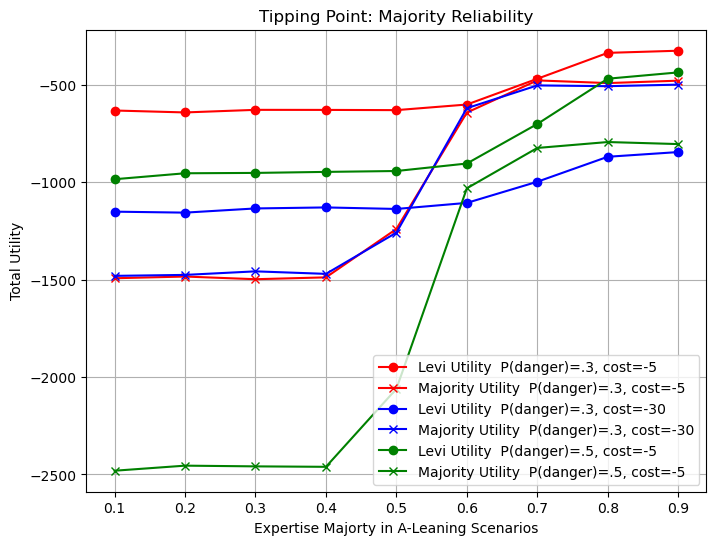

In [63]:
df_maj1 = run_test_suite('Majority Accuracy', np.linspace(.1, .9, 9), .3, .6, .2, -5)
df_maj2 = run_test_suite('Majority Accuracy', np.linspace(.1, .9, 9), .3, .6, .2, -30)
df_maj3 = run_test_suite('Majority Accuracy', np.linspace(.1, .9, 9), .5, .6, .2, -5)

fig, axx = plt.subplots(1, 1, figsize=(8, 6))

axx.plot(df_maj1['Parameter'], df_maj1['Levi_Util_Mean'],
         label='Levi Utility  P(danger)=.3, cost=-5', marker='o', color='red')
axx.plot(df_maj1['Parameter'], df_maj1['Maj_Util_Mean'],
         label='Majority Utility  P(danger)=.3, cost=-5', marker='x', color='red')
axx.plot(df_maj2['Parameter'], df_maj2['Levi_Util_Mean'],
         label='Levi Utility  P(danger)=.3, cost=-30', marker='o', color='blue')
axx.plot(df_maj2['Parameter'], df_maj2['Maj_Util_Mean'],
         label='Majority Utility  P(danger)=.3, cost=-30', marker='x', color='blue')
axx.plot(df_maj3['Parameter'], df_maj3['Levi_Util_Mean'],
         label='Levi Utility  P(danger)=.5, cost=-5', marker='o', color='green')
axx.plot(df_maj3['Parameter'], df_maj3['Maj_Util_Mean'],
         label='Majority Utility  P(danger)=.5, cost=-5', marker='x', color='green')

axx.set_title('Tipping Point: Majority Reliability')
axx.set_xlabel('Expertise Majorty in A-Leaning Scenarios')
axx.set_ylabel('Total Utility')
axx.legend()
axx.grid(True)

plt.show()

Test suite 2:
- tipping point - expertise

Running sweep for Minority Accuracy...
Running sweep for Minority Accuracy...
Running sweep for Minority Accuracy...
Running sweep for Minority Accuracy...
Running sweep for Minority Accuracy...
Running sweep for Minority Accuracy...


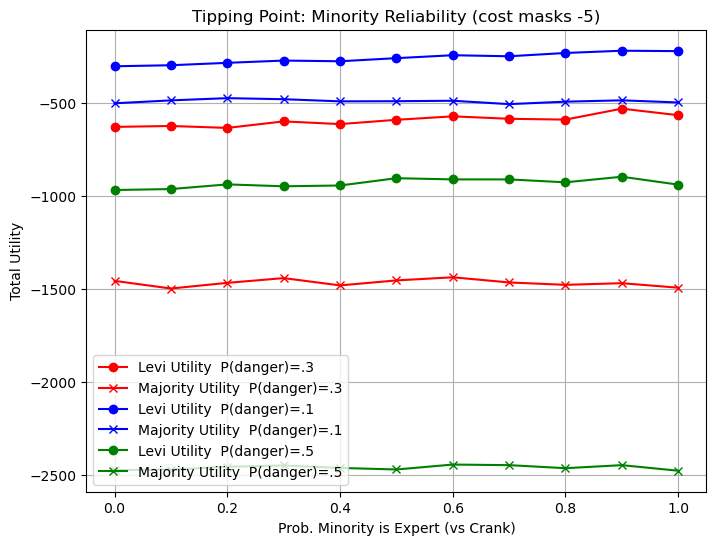

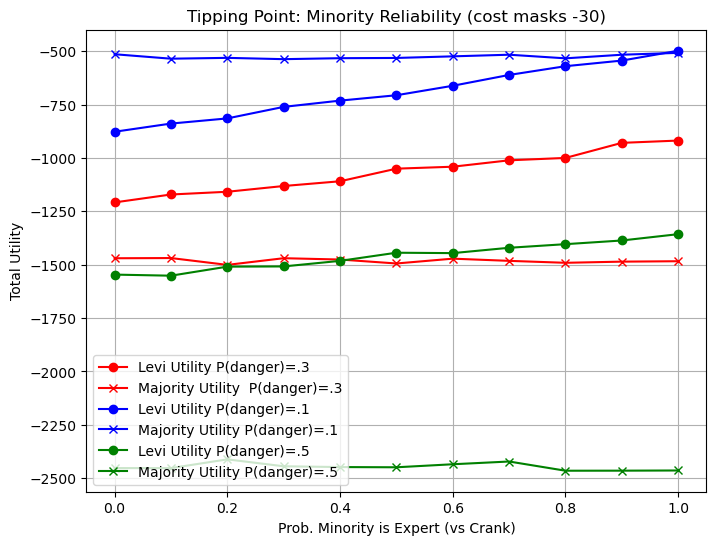

In [64]:
# TEST 2: The Tipping Point of Expertise
# We vary the probability that the minority is an Expert vs a Crank.
# 0.0 = Always Crank, 1.0 = Always Expert.
df_expert1 = run_test_suite('Minority Accuracy', np.linspace(0, 1, 11), .3, .6, .2, -5)
df_expert2 = run_test_suite('Minority Accuracy', np.linspace(0, 1, 11), .1, .6, .2, -5)
df_expert3 = run_test_suite('Minority Accuracy', np.linspace(0, 1, 11), .5, .6, .2, -5)
df_expert21 = run_test_suite('Minority Accuracy', np.linspace(0, 1, 11), .3, .4, .2, -30)
df_expert22 = run_test_suite('Minority Accuracy', np.linspace(0, 1, 11), .1, .4, .2, -30)
df_expert23 = run_test_suite('Minority Accuracy', np.linspace(0, 1, 11), .5, .4, .2, -30)
# --- PLOTTING ---
fig, ax2 = plt.subplots(1, 1, figsize=(8, 6))


# Plot 2: Accuracy Sensitivity
ax2.plot(df_expert1['Parameter'], df_expert1['Levi_Util_Mean'],
         label='Levi Utility  P(danger)=.3', marker='o', color='red')
ax2.plot(df_expert1['Parameter'], df_expert1['Maj_Util_Mean'],
         label='Majority Utility  P(danger)=.3', marker='x', color='red')
ax2.plot(df_expert2['Parameter'], df_expert2['Levi_Util_Mean'],
         label='Levi Utility  P(danger)=.1', marker='o', color='blue')
ax2.plot(df_expert2['Parameter'], df_expert2['Maj_Util_Mean'],
         label='Majority Utility  P(danger)=.1', marker='x', color='blue')
ax2.plot(df_expert3['Parameter'], df_expert3['Levi_Util_Mean'],
         label='Levi Utility  P(danger)=.5', marker='o', color='green')
ax2.plot(df_expert3['Parameter'], df_expert3['Maj_Util_Mean'],
         label='Majority Utility  P(danger)=.5', marker='x', color='green')
ax2.set_title('Tipping Point: Minority Reliability (cost masks -5)')
ax2.set_xlabel('Prob. Minority is Expert (vs Crank)')
ax2.set_ylabel('Total Utility')
ax2.legend()
ax2.grid(True)

plt.show()

fig, ax22 = plt.subplots(1, 1, figsize=(8, 6))
ax22.plot(df_expert21['Parameter'], df_expert21['Levi_Util_Mean'],
         label='Levi Utility P(danger)=.3', marker='o', color='red')
ax22.plot(df_expert21['Parameter'], df_expert21['Maj_Util_Mean'],
         label='Majority Utility  P(danger)=.3', marker='x', color='red')
ax22.plot(df_expert22['Parameter'], df_expert22['Levi_Util_Mean'],
         label='Levi Utility P(danger)=.1', marker='o', color='blue')
ax22.plot(df_expert22['Parameter'], df_expert22['Maj_Util_Mean'],
         label='Majority Utility P(danger)=.1', marker='x', color='blue')
ax22.plot(df_expert23['Parameter'], df_expert23['Levi_Util_Mean'],
         label='Levi Utility P(danger)=.5', marker='o', color='green')
ax22.plot(df_expert23['Parameter'], df_expert23['Maj_Util_Mean'],
         label='Majority Utility P(danger)=.5', marker='x', color='green')
ax22.set_title('Tipping Point: Minority Reliability (cost masks -30)')
ax22.set_xlabel('Prob. Minority is Expert (vs Crank)')
ax22.set_ylabel('Total Utility')
ax22.legend()
ax22.grid(True)

plt.show()

Test suite 3
- unforgiving vs forgiving culture

In [43]:
# --- TRUST TEST SUITE ---

def run_trust_sweep(parameter_name, parameter_values, ground_truth_prob, leaning_prob, 
                    polarization_prob, fpcost, leaning_maj_mean_u, n_runs=400):
    results = []
    print(f"Running trust sweep for {parameter_name}...")

    for val in parameter_values:
        levi_trusts = []
        maj_trusts = []

        for _ in range(n_runs):
            # Default settings
            kwargs = {
                # Assume worst case (Cranks) to stress test
                'minority_type': 'crank',
                'base_penalty': 0.05,
                'mitigation_factor': 1.0,
                'fp_cost': fpcost,
                'ground_p': ground_truth_prob,
                'leaning_p': leaning_prob,
                'polarization_p': polarization_prob,
                'leaning_maj_mean_u': leaning_maj_mean_u,
            }

            # Inject parameter
            if parameter_name == 'Penalty Severity':
                kwargs['base_penalty'] = val
            elif parameter_name == 'Public Sophistication':
                kwargs['mitigation_factor'] = val

            sim = Simulation(**kwargs)
            for _ in range(50): # 50 Rounds
                sim.run_round()

            levi_trusts.append(sim.trust_scores['Levi'])
            maj_trusts.append(sim.trust_scores['Majority'])

        results.append({
            'Parameter': val,
            'Levi_Trust_Mean': np.mean(levi_trusts),
            'Maj_Trust_Mean': np.mean(maj_trusts)
        })

    return pd.DataFrame(results)


Running trust sweep for Penalty Severity...
Running trust sweep for Penalty Severity...
Running trust sweep for Penalty Severity...


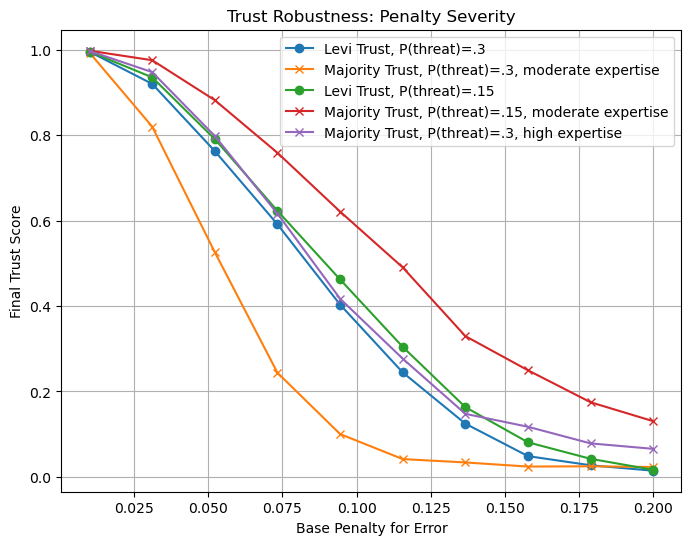

In [73]:
# TEST 3: The "Unforgiving Public"
# Vary penalty from 0.01 (Gentle) to 0.20 (Harsh/Cancel Culture)
df_penalty = run_trust_sweep('Penalty Severity', np.linspace(0.01, 0.2, 10), .3, .6, .2, -5, .4)
df_penalty3 = run_trust_sweep('Penalty Severity', np.linspace(0.01, 0.2, 10), .15, .6, .2, -5, .4)
df_penalty2 = run_trust_sweep('Penalty Severity', np.linspace(0.01, 0.2, 10), .3, .6, .2, -5, .55)

# --- PLOTTING ---
fig, ax3 = plt.subplots(1, 1, figsize=(8, 6))

ax3.plot(df_penalty['Parameter'], df_penalty['Levi_Trust_Mean'],
         label='Levi Trust, P(threat)=.3', marker='o')
ax3.plot(df_penalty['Parameter'], df_penalty['Maj_Trust_Mean'],
         label='Majority Trust, P(threat)=.3, moderate expertise', marker='x')
ax3.plot(df_penalty3['Parameter'], df_penalty3['Levi_Trust_Mean'],
          label='Levi Trust, P(threat)=.15', marker='o')
ax3.plot(df_penalty3['Parameter'], df_penalty3['Maj_Trust_Mean'],
         label='Majority Trust, P(threat)=.15, moderate expertise', marker='x')
# ax3.plot(df_penalty2['Parameter'], df_penalty2['Levi_Trust_Mean'],
 #        label='Levi Trust, P(threat)=.3', marker='o')
ax3.plot(df_penalty2['Parameter'], df_penalty2['Maj_Trust_Mean'],
         label='Majority Trust, P(threat)=.3, high expertise', marker='x')
ax3.set_title('Trust Robustness: Penalty Severity')
ax3.set_xlabel('Base Penalty for Error')
ax3.set_ylabel('Final Trust Score')
ax3.legend()
ax3.grid(True)

plt.show()

Test Suite 4:
- outcome bias vs process trust

In [79]:
# TEST 4: The "Outcome Bias" vs "Process Trust"
# Vary mitigation from 0.0 (Pure Outcome Bias) to 1.0 (Understanding/Nuanced)
# 0.0 means: "I don't care that you were unsure, you were wrong."
# 1.0 means: "I forgive you because you told me it was uncertain."
df_sophistication = run_trust_sweep('Public Sophistication',
                                    np.linspace(0, 1, 11), .3, .6, .2, -5, .4)
df_sophistication2 = run_trust_sweep('Public Sophistication',
                                    np.linspace(0, 1, 11), .4, .6, .2, -5, .4)
df_sophistication3 = run_trust_sweep('Public Sophistication',
                                    np.linspace(0, 1, 11), .4, .6, .2, -5, .6)
df_sophistication4 = run_trust_sweep('Public Sophistication',
                                    np.linspace(0, 1, 11), .15, .6, .2, -5, .4)

Running trust sweep for Public Sophistication...
Running trust sweep for Public Sophistication...
Running trust sweep for Public Sophistication...
Running trust sweep for Public Sophistication...


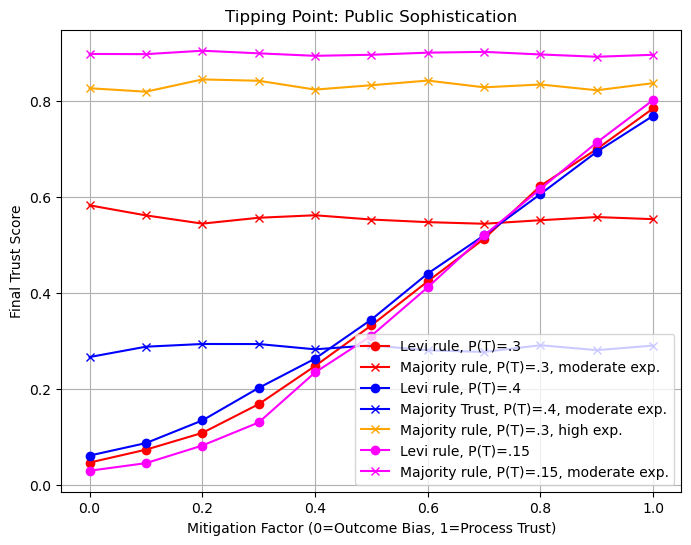

In [80]:
fig, ax4 = plt.subplots(1, 1, figsize=(8, 6))

ax4.plot(df_sophistication['Parameter'], df_sophistication['Levi_Trust_Mean'], 
         label='Levi rule, P(T)=.3', marker='o', color='red')
ax4.plot(df_sophistication['Parameter'], df_sophistication['Maj_Trust_Mean'], 
         label='Majority rule, P(T)=.3, moderate exp.', marker='x', color='red')
ax4.plot(df_sophistication2['Parameter'], df_sophistication2['Levi_Trust_Mean'], 
          label='Levi rule, P(T)=.4', marker='o', color='blue')
ax4.plot(df_sophistication2['Parameter'], df_sophistication2['Maj_Trust_Mean'], 
          label='Majority Trust, P(T)=.4, moderate exp.', marker='x', color='blue')
# ax4.plot(df_sophistication3['Parameter'], df_sophistication3['Levi_Trust_Mean'], 
#          label='Levi Trust, P(threat)=.3', marker='o')
ax4.plot(df_sophistication3['Parameter'], df_sophistication3['Maj_Trust_Mean'], 
         label='Majority rule, P(T)=.3, high exp.', marker='x', color='orange')
ax4.plot(df_sophistication['Parameter'], df_sophistication4['Levi_Trust_Mean'], 
         label='Levi rule, P(T)=.15', marker='o', color='magenta')
ax4.plot(df_sophistication['Parameter'], df_sophistication4['Maj_Trust_Mean'], 
         label='Majority rule, P(T)=.15, moderate exp.', marker='x', color='magenta')

ax4.set_title('Tipping Point: Public Sophistication')
ax4.set_xlabel('Mitigation Factor (0=Outcome Bias, 1=Process Trust)')
ax4.set_ylabel('Final Trust Score')
ax4.legend()
ax4.grid(True)

plt.show()